# Run and Evaluate the CN3S Model

In [2]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import pandas as pd

from cn3s import CN3S, CN3SOptimizer, CN3SParams
from utils import load_data


## Select Basin

In [9]:
BASIN = "PortoMurtinho"
FREQ = "M"  # "D" for daily, "M" for monthly

path, data = load_data(BASIN, freq=FREQ)

In [10]:
data.keys()

dict_keys(['station', 'area', 'prec', 'q', 'shp'])

## Test Distinct Warmup Periods

In [11]:
from cn3s.objectives import Objectives

model = CN3S(CN3SParams(area=data["area"], warmup_steps=1), freq=FREQ)

if FREQ == "D":
    sliced_prec = data["prec"]["prec"].iloc[-3000:-1000]
    freq = "Daily"
else:
    sliced_prec = data["prec"]["prec"]
    freq = "Monthly"

freq


'Monthly'

In [12]:
for warmup_steps in range(1, 21, 1):
    print(20 * "-")
    print(f"Optimizing with {warmup_steps} warmup steps...")
    model.params.warmup_steps = warmup_steps

    optim = CN3SOptimizer(
        prec=sliced_prec,
        observed_q=data["q"]["Vazao"],
        model=model,
        train_ratio=0.8,
        max_act=10,
        objective=Objectives.PlainNSE,
    )

    optim.optimize(maxiter=50, tol=1e-4, disp=False, workers=-1, x0=None)

    history = optim.history
    history.to_pickle(path / f"{freq}_history_PlainNSE_{warmup_steps}_Steps.pkl")

--------------------
Optimizing with 1 warmup steps...


/usr/local/lib/python3.12/dist-packages/scipy/optimize/_differentialevolution.py:487: UserWarning: differential_evolution: the 'workers' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


1 - Train objective: 654.3190 - [167.49, 37.73, 0.65, 0.29, 0.35, 0.04, 0.35, 0.0]
2 - Train objective: 654.3190 - [167.49, 37.73, 0.65, 0.29, 0.35, 0.04, 0.35, 0.0]
3 - Train objective: 634.6781 - [97.45, 34.21, 0.46, 0.11, 0.65, 0.06, 0.45, 0.0]
4 - Train objective: 537.7265 - [163.84, 31.31, 0.28, 0.03, 0.18, 0.73, 0.49, 0.0]
5 - Train objective: 537.7265 - [163.84, 31.31, 0.28, 0.03, 0.18, 0.73, 0.49, 0.0]
6 - Train objective: 537.7265 - [163.84, 31.31, 0.28, 0.03, 0.18, 0.73, 0.49, 0.0]
7 - Train objective: 457.7279 - [755.37, 14.69, 0.37, 0.04, 0.21, 0.31, 0.26, 0.0]
8 - Train objective: 457.7279 - [755.37, 14.69, 0.37, 0.04, 0.21, 0.31, 0.26, 0.0]
9 - Train objective: 457.7279 - [755.37, 14.69, 0.37, 0.04, 0.21, 0.31, 0.26, 0.0]
10 - Train objective: 457.7279 - [755.37, 14.69, 0.37, 0.04, 0.21, 0.31, 0.26, 0.0]
11 - Train objective: 457.7279 - [755.37, 14.69, 0.37, 0.04, 0.21, 0.31, 0.26, 0.0]
12 - Train objective: 457.7279 - [755.37, 14.69, 0.37, 0.04, 0.21, 0.31, 0.26, 0.0]
13

/usr/local/lib/python3.12/dist-packages/scipy/optimize/_differentialevolution.py:487: UserWarning: differential_evolution: the 'workers' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


1 - Train objective: 648.1102 - [167.49, 37.73, 0.65, 0.29, 0.35, 0.04, 0.35, 0.0]
2 - Train objective: 648.1102 - [167.49, 37.73, 0.65, 0.29, 0.35, 0.04, 0.35, 0.0]
3 - Train objective: 635.6172 - [97.45, 34.21, 0.46, 0.11, 0.65, 0.06, 0.45, 0.0]
4 - Train objective: 583.5421 - [163.84, 31.31, 0.28, 0.03, 0.18, 0.73, 0.49, 0.0]
5 - Train objective: 583.5421 - [163.84, 31.31, 0.28, 0.03, 0.18, 0.73, 0.49, 0.0]
6 - Train objective: 583.5421 - [163.84, 31.31, 0.28, 0.03, 0.18, 0.73, 0.49, 0.0]
7 - Train objective: 541.3751 - [755.37, 14.69, 0.37, 0.04, 0.21, 0.31, 0.26, 0.0]
8 - Train objective: 541.3751 - [755.37, 14.69, 0.37, 0.04, 0.21, 0.31, 0.26, 0.0]
9 - Train objective: 541.3751 - [755.37, 14.69, 0.37, 0.04, 0.21, 0.31, 0.26, 0.0]
10 - Train objective: 541.3751 - [755.37, 14.69, 0.37, 0.04, 0.21, 0.31, 0.26, 0.0]
11 - Train objective: 541.3751 - [755.37, 14.69, 0.37, 0.04, 0.21, 0.31, 0.26, 0.0]
12 - Train objective: 541.3751 - [755.37, 14.69, 0.37, 0.04, 0.21, 0.31, 0.26, 0.0]
13

...

1 - Train objective: 618.9149 - [101.83, 93.65, 0.32, 0.25, 0.24, 0.92, 0.99, 0.0]
2 - Train objective: 618.8611 - [53.57, 37.57, 0.42, 0.04, 0.6, 0.91, 0.81, 0.0]
3 - Train objective: 616.3818 - [122.56, 48.18, 0.76, 0.34, 0.02, 0.47, 0.92, 0.0]
4 - Train objective: 616.3818 - [122.56, 48.18, 0.76, 0.34, 0.02, 0.47, 0.92, 0.0]
5 - Train objective: 616.0581 - [79.38, 35.66, 0.82, 0.46, 0.09, 0.69, 0.88, 0.0]
6 - Train objective: 615.9427 - [54.59, 93.33, 0.76, 0.34, 0.08, 0.47, 0.87, 0.0]
7 - Train objective: 615.9427 - [54.59, 93.33, 0.76, 0.34, 0.08, 0.47, 0.87, 0.0]
8 - Train objective: 615.9427 - [54.59, 93.33, 0.76, 0.34, 0.08, 0.47, 0.87, 0.0]
9 - Train objective: 614.3109 - [106.78, 79.36, 0.54, 0.08, 0.23, 0.19, 0.91, 0.0]
10 - Train objective: 484.1027 - [93.25, 34.05, 0.95, 0.03, 0.36, 0.44, 0.99, 0.0]
11 - Train objective: 484.1027 - [93.25, 34.05, 0.95, 0.03, 0.36, 0.44, 0.99, 0.0]
12 - Train objective: 439.0729 - [111.61, 2.29, 0.98, 0.03, 0.61, 0.2, 0.56, 0.0]
13 - Train 

/usr/local/lib/python3.12/dist-packages/scipy/optimize/_differentialevolution.py:487: UserWarning: differential_evolution: the 'workers' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


1 - Train objective: 618.9858 - [101.83, 93.65, 0.32, 0.25, 0.24, 0.92, 0.99, 0.0]
2 - Train objective: 618.9858 - [101.83, 93.65, 0.32, 0.25, 0.24, 0.92, 0.99, 0.0]
3 - Train objective: 618.1013 - [95.58, 105.44, 0.69, 0.81, 0.06, 0.37, 0.75, 0.0]
4 - Train objective: 617.8178 - [91.22, 87.0, 0.63, 0.34, 0.04, 0.38, 0.69, 0.0]
5 - Train objective: 617.4788 - [78.43, 95.24, 0.74, 0.56, 0.3, 0.64, 0.64, 0.0]
6 - Train objective: 616.3295 - [56.56, 121.59, 0.67, 0.55, 0.31, 0.89, 0.97, 0.0]
7 - Train objective: 615.3882 - [53.57, 37.57, 0.85, 0.45, 0.31, 0.44, 0.81, 0.0]
8 - Train objective: 615.2043 - [56.56, 49.81, 0.27, 0.29, 0.35, 0.1, 0.72, 0.0]
9 - Train objective: 604.2923 - [67.84, 72.28, 0.62, 0.05, 0.28, 0.14, 0.82, 0.0]
10 - Train objective: 226.2993 - [273.39, 79.9, 0.91, 0.0, 0.05, 0.4, 0.87, 0.0]
11 - Train objective: 226.2993 - [273.39, 79.9, 0.91, 0.0, 0.05, 0.4, 0.87, 0.0]
12 - Train objective: 226.2993 - [273.39, 79.9, 0.91, 0.0, 0.05, 0.4, 0.87, 0.0]
13 - Train objecti

/usr/local/lib/python3.12/dist-packages/scipy/optimize/_differentialevolution.py:487: UserWarning: differential_evolution: the 'workers' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


1 - Train objective: 622.7963 - [101.83, 93.65, 0.32, 0.25, 0.24, 0.92, 0.99, 0.0]
2 - Train objective: 621.2632 - [53.57, 37.57, 0.42, 0.04, 0.6, 0.91, 0.81, 0.0]
3 - Train objective: 620.2523 - [122.56, 48.18, 0.76, 0.34, 0.02, 0.47, 0.92, 0.0]
4 - Train objective: 620.2523 - [122.56, 48.18, 0.76, 0.34, 0.02, 0.47, 0.92, 0.0]
5 - Train objective: 619.4655 - [79.38, 35.66, 0.82, 0.46, 0.09, 0.69, 0.88, 0.0]
6 - Train objective: 618.5544 - [54.59, 93.33, 0.76, 0.34, 0.08, 0.47, 0.87, 0.0]
7 - Train objective: 618.5544 - [54.59, 93.33, 0.76, 0.34, 0.08, 0.47, 0.87, 0.0]
8 - Train objective: 617.9975 - [85.11, 84.18, 0.82, 0.04, 0.33, 0.51, 0.74, 0.0]
9 - Train objective: 617.9975 - [85.11, 84.18, 0.82, 0.04, 0.33, 0.51, 0.74, 0.0]
10 - Train objective: 537.6436 - [454.42, 10.27, 0.75, 0.01, 0.16, 0.89, 0.91, 0.0]
11 - Train objective: 537.3660 - [255.65, 2.72, 0.85, 0.05, 0.21, 0.62, 1.0, 0.0]
12 - Train objective: 29.7324 - [364.44, 27.77, 0.65, 0.01, 0.46, 0.24, 0.33, 0.0]
13 - Train 

In [6]:
optim.plot_step(50)

## Visualize Warmup Period Sensitivity

In [49]:
BASIN = "RioBranco"
FREQ = "D"  # "D" for daily, "M" for monthly

path, data = load_data(BASIN, freq=FREQ)

<Axes: xlabel='time'>

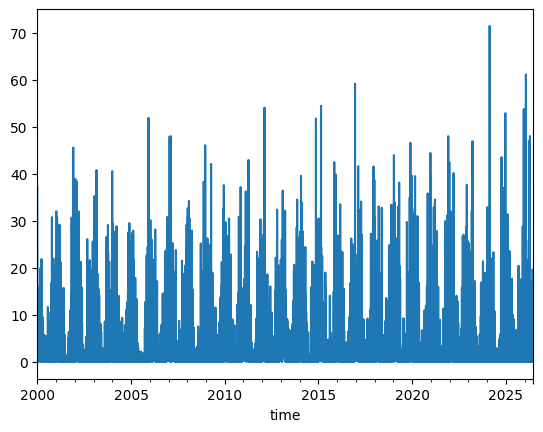

In [69]:
data["prec"]["prec"].plot()

In [51]:
FREQS = ["Daily", "Monthly"]
FREQS = ["Daily"]

history = {
    freq: {
        step: pd.read_pickle(f"/data/CN3S/basins/{BASIN}/{freq}_history_PlainNSE_{step}_Steps.pkl")
        for step in range(1, 14, 1)
    }
    for freq in FREQS
}


In [54]:
best_history = {
    freq: pd.DataFrame(
        [history[freq][step].iloc[-1] for step in range(1, 14, 1)],
        index=range(1, 14, 1),
    )
    for freq in FREQS
}

In [57]:
df = best_history["Daily"]
df.index.name = "Warmup Steps"
df["train_nse"] = 1 - df["train_objective"]
df

,train_objective,test_objective,train_nse,test_nse,r0,cn_i,alfa,beta,k0,k1,k2,act,params
Warmup Steps,,,,,,,,,,,,,
1,1.576435,None,-0.576435,None,987.337104,81.308306,0.213980,0.049345,0.596752,0.999214,0.083574,4,"CN3SParams(name='Unnamed', area=27898.35854781..."
2,1.574086,None,-0.574086,None,989.745674,78.559272,0.106525,0.055151,0.654973,0.998605,0.067750,4,"CN3SParams(name='Unnamed', area=27898.35854781..."
3,1.572443,None,-0.572443,None,986.912127,72.060878,0.114650,0.074490,0.809387,0.998750,0.060070,4,"CN3SParams(name='Unnamed', area=27898.35854781..."
4,1.574219,None,-0.574219,None,983.894241,52.305248,0.459852,0.093600,0.859808,0.999349,0.071597,4,"CN3SParams(name='Unnamed', area=27898.35854781..."
5,1.573398,None,-0.573398,None,987.888340,37.976998,0.087998,0.121877,0.860825,0.998282,0.065218,4,"CN3SParams(name='Unnamed', area=27898.35854781..."
6,1.570396,None,-0.570396,None,996.535675,57.907499,0.217924,0.055049,0.974380,0.999246,0.047321,4,"CN3SParams(name='Unnamed', area=27898.35854781..."
7,1.570217,None,-0.570217,None,954.637839,49.771926,0.233128,0.059716,0.959739,0.998701,0.049797,4,"CN3SParams(name='Unnamed', area=27898.35854781..."
8,1.570276,None,-0.570276,None,996.466961,58.271627,0.165635,0.057110,0.859251,0.996716,0.049848,4,"CN3SParams(name='Unnamed', area=27898.35854781..."
9,1.571020,None,-0.571020,None,935.007019,61.091874,0.680135,0.050906,0.990758,0.998648,0.035011,4,"CN3SParams(name='Unnamed', area=27898.35854781..."


Text(0.5, 0, 'Warmup Steps')

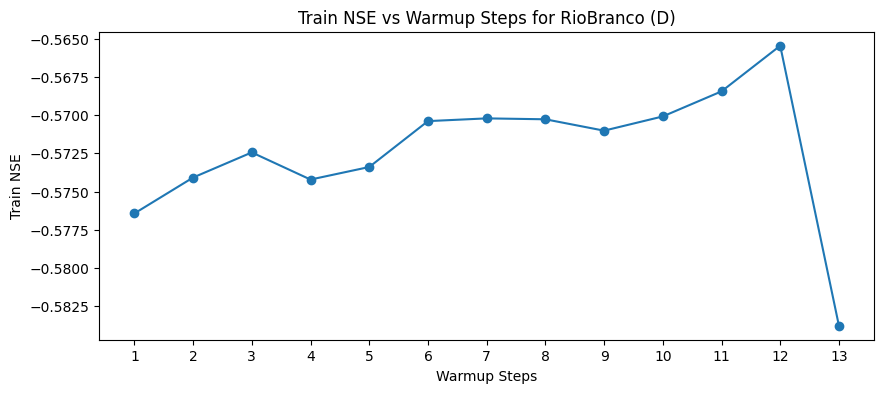

In [66]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    df.index.astype(str),
    df["train_nse"],
    marker="o",
    scaley=True,
)
ax.set_title(f"Train NSE vs Warmup Steps for {BASIN} ({FREQ})")
ax.set_ylabel("Train NSE")
ax.set_xlabel("Warmup Steps")


In [59]:
BASIN = "RioBranco"
FREQ = "D"  # "D" for daily, "M" for monthly
STEPS = 4

path, data = load_data(BASIN, freq=FREQ)
prec = data["prec"]["prec"].iloc[-3000:-1000]

In [61]:
optim = CN3SOptimizer(
    prec=prec,
    observed_q=data["q"]["Vazao"],
    model=CN3S(CN3SParams(area=data["area"], warmup_steps=STEPS)),
    train_ratio=0.8,
    max_act=10,
    objective=Objectives.PlainNSE,
)

optim.history = history["Daily"][STEPS]

optim.evaluate_step(50)

{'train_objective': 1.5742185634659314,
 'test_objective': 1.311045003681609,
 'train_nse': -0.5742185634659314,
 'test_nse': -0.31104500368160903}

In [62]:
optim.history.tail()

,train_objective,test_objective,train_nse,test_nse,r0,cn_i,alfa,beta,k0,k1,k2,act,params
step,,,,,,,,,,,,,
46,1.574284,None,None,None,994.732699,41.726208,0.336013,0.086603,0.811489,0.999145,0.067585,4,"CN3SParams(name='Unnamed', area=27898.35854781..."
47,1.574284,None,None,None,994.732699,41.726208,0.336013,0.086603,0.811489,0.999145,0.067585,4,"CN3SParams(name='Unnamed', area=27898.35854781..."
48,1.574284,None,None,None,994.732699,41.726208,0.336013,0.086603,0.811489,0.999145,0.067585,4,"CN3SParams(name='Unnamed', area=27898.35854781..."
49,1.574284,None,None,None,994.732699,41.726208,0.336013,0.086603,0.811489,0.999145,0.067585,4,"CN3SParams(name='Unnamed', area=27898.35854781..."
50,1.574219,1.311045,-0.574219,-0.311045,983.894241,52.305248,0.459852,0.0936,0.859808,0.999349,0.071597,4,"CN3SParams(name='Unnamed', area=27898.35854781..."


In [63]:
optim.plot_step(50)

In [64]:
optim.model.last_vj

[2.39680891709194,
 3.0758678098954118,
 2.0392312314448375,
 1.733468634543173,
 1.9315047795188365,
 1.948951419981809,
 1.9456910064270132,
 1.8853740122807385,
 1.572790991223926,
 1.1477949310841788,
 1.0639532957533713,
 1.110329826226296,
 1.098076486148433,
 1.0962912826876785,
 1.229871744820989,
 1.241575252797019,
 2.9753998928649326,
 4.270011222697821,
 3.878846853622145,
 3.4996401116139353,
 2.5080541590289975,
 1.722890789964021,
 1.7144588223638788,
 1.7398520519557659,
 1.5422513948421281,
 1.3250101095546076,
 1.2032620604543647,
 1.2586649700120576,
 1.3035951111564077,
 1.2834783716729607,
 1.3446491678146648,
 1.2758340750905812,
 1.211958651567803,
 1.5883823730311895,
 1.6585830658812357,
 1.5250566247288273,
 1.427162929022986,
 1.1357909203980412,
 1.5762722456792373,
 1.666983170630938,
 1.5734776858983879,
 4.564279602024394,
 3.7496525969776,
 3.2704461884422877,
 2.9521485450270264,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0023642560310122,
 1.0024571606611425,
 1.04027

In [ ]:
df = pd.DataFrame(
    data={
        "Diário": [1 - history["train_objective"].iloc[-1] for history in daily_acc.values()],
        "Mensal": [1 - history["train_objective"].iloc[-1] for history in monthly_acc.values()],
    },
    index=list(daily_acc.keys()),
)

df.index.name = "Warmup Steps"
df.plot(
    title="Evolução do NSE em função do número de Warmup Steps\nRIO BRANCO",
    ylabel="NSE",
    xlabel="Warmup Steps",
)

In [26]:
params = monthly_acc[5].loc[25]["params"]
print(params)

model = CN3S(params)

model.run(sliced_prec)


CN3SParams(name='Unnamed', area=27898.35854781605, r0=142.71166121913103, cn_i=23.431385889621453, alfa=56.1956099757509, beta=1.081327781813469, k0=27.245104257090166, k1=0.3220592921060508, k2=0.5036768643523423, act=0, warmup_steps=5)


Running CN3S model:   0%|          | 0/311 [00:00<?, ?step/s]

In [27]:
model.last_vj

[5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0,
 5.0

In [18]:
len(init_params)

8

In [133]:
STEPS = 19

model = CN3S(CN3SParams(area=data["area"], warmup_steps=STEPS))

optim = CN3SOptimizer(
    prec=sliced_prec,
    observed_q=data["q"]["Vazao"],
    model=model,
    train_ratio=0.8,
    max_act=10,
    objective=Objectives.PlainNSE,
)

optim.history = daily_acc[STEPS]

optim.evaluate_step(50)

{'train_objective': 0.24472954549793147,
 'test_objective': 0.5311309965340091,
 'train_nse': 0.7552704545020685,
 'test_nse': 0.4688690034659909}

In [134]:
optim.model.evaluate(optim.model.results["obs_q_m3s"])
optim.model.plot()

Aligned 1981 time steps between model results and observations.
From 2018-04-27 00:00:00 to 2023-09-28 00:00:00.


In [135]:
optim.model.results

,prec,past_prec,vj,cnv,s,q_up,r1,q_low,r,q_mm,q_m3s,obs_q_m3s
time,,,,,,,,,,,,
2018-04-27,18.917746,"[1.0236399173736572, 1.6175518035888672, 0.174...",5.0,99.798099,0.513866,0.0,726.089501,35.148109,690.941392,35.148109,378.308082,401.62
2018-04-28,16.885363,"[18.91774559020996, 1.0236399173736572, 1.6175...",5.0,99.798099,0.513866,0.0,868.294356,42.031877,826.262479,42.031877,452.399838,360.62
2018-04-29,1.602655,"[16.88536262512207, 18.91774559020996, 1.02363...",5.0,99.798099,0.513866,0.0,843.095738,40.812077,802.283661,40.812077,439.270822,358.67
2018-04-30,0.819948,"[1.6026554107666016, 16.88536262512207, 18.917...",5.0,99.798099,0.513866,0.0,810.895868,39.253365,771.642503,39.253365,422.494004,356.72
2018-05-01,3.48899,"[0.8199481964111328, 1.6026554107666016, 16.88...",5.0,99.798099,0.513866,0.0,808.2886,39.127154,769.161446,39.127154,421.135562,339.37
...,...,...,...,...,...,...,...,...,...,...,...,...
2023-09-24,0.025907,"[7.028497219085693, 0.43199482560157776, 0.012...",5.0,99.798099,0.513866,0.0,245.700163,11.893707,233.806456,11.893707,128.015014,30.28
2023-09-25,0.292746,"[0.02590673603117466, 7.028497219085693, 0.431...",5.0,99.798099,0.513866,0.0,236.881273,11.466808,225.414465,11.466808,123.420184,30.28
2023-09-26,0.0,"[0.2927461266517639, 0.02590673603117466, 7.02...",5.0,99.798099,0.513866,0.0,225.414465,10.911729,214.502735,10.911729,117.445733,29.57


In [136]:
optim.history

,train_objective,test_objective,train_nse,test_nse,r0,cn_i,alfa,beta,k0,k1,k2,act,params
step,,,,,,,,,,,,,
1,0.530007,None,None,None,400.854897,13.729838,8.778826,17.791671,17.15968,13.753107,0.063891,10,"CN3SParams(name='Unnamed', area=27898.35854781..."
2,0.428511,None,None,None,819.989119,9.664284,46.123651,2.826341,4.195522,12.242645,0.097682,7,"CN3SParams(name='Unnamed', area=27898.35854781..."
3,0.425334,None,None,None,850.510584,5.661158,38.231369,3.276056,0.977427,9.692168,0.14651,9,"CN3SParams(name='Unnamed', area=27898.35854781..."
4,0.3224,None,None,None,753.059566,15.408004,65.52308,5.720239,6.265097,9.942927,0.097444,6,"CN3SParams(name='Unnamed', area=27898.35854781..."
5,0.310148,None,None,None,411.729467,33.008234,53.201854,13.279149,12.959633,12.554554,0.03143,2,"CN3SParams(name='Unnamed', area=27898.35854781..."
6,0.310148,None,None,None,411.729467,33.008234,53.201854,13.279149,12.959633,12.554554,0.03143,2,"CN3SParams(name='Unnamed', area=27898.35854781..."
7,0.269499,None,None,None,710.938557,24.785775,33.987139,7.923916,9.138846,9.847723,0.039617,4,"CN3SParams(name='Unnamed', area=27898.35854781..."
8,0.269499,None,None,None,710.938557,24.785775,33.987139,7.923916,9.138846,9.847723,0.039617,4,"CN3SParams(name='Unnamed', area=27898.35854781..."
9,0.257334,None,None,None,419.329188,20.913529,57.066717,11.219796,22.437599,11.002091,0.037107,1,"CN3SParams(name='Unnamed', area=27898.35854781..."


In [53]:
optim.history = daily_acc[3]

In [51]:
daily_acc[1]

,train_objective,test_objective,train_nse,test_nse,r0,cn_i,alfa,beta,k0,k1,k2,act,params
step,,,,,,,,,,,,,
1,0.530347,None,None,None,400.854897,13.729838,8.778826,17.791671,17.15968,13.753107,0.063891,10,"CN3SParams(name='Unnamed', area=27898.35854781..."
2,0.530347,None,None,None,400.854897,13.729838,8.778826,17.791671,17.15968,13.753107,0.063891,10,"CN3SParams(name='Unnamed', area=27898.35854781..."
3,0.312404,None,None,None,667.647844,20.683863,17.939006,14.61532,26.235646,9.111506,0.045102,6,"CN3SParams(name='Unnamed', area=27898.35854781..."
4,0.30139,None,None,None,732.434525,30.848842,7.21132,14.550504,14.776928,9.539895,0.03013,3,"CN3SParams(name='Unnamed', area=27898.35854781..."
5,0.30139,None,None,None,732.434525,30.848842,7.21132,14.550504,14.776928,9.539895,0.03013,3,"CN3SParams(name='Unnamed', area=27898.35854781..."
6,0.30139,None,None,None,732.434525,30.848842,7.21132,14.550504,14.776928,9.539895,0.03013,3,"CN3SParams(name='Unnamed', area=27898.35854781..."
7,0.286258,None,None,None,616.544005,13.456396,95.536996,6.616063,21.80219,10.934594,0.031546,4,"CN3SParams(name='Unnamed', area=27898.35854781..."
8,0.268709,None,None,None,862.289453,15.760103,35.759231,12.786784,27.624295,9.565206,0.065011,4,"CN3SParams(name='Unnamed', area=27898.35854781..."
9,0.268709,None,None,None,862.289453,15.760103,35.759231,12.786784,27.624295,9.565206,0.065011,4,"CN3SParams(name='Unnamed', area=27898.35854781..."


In [42]:
monthly_acc.keys()

dict_keys([1, 3, 5, 7, 9, 11, 13, 15, 17, 19])

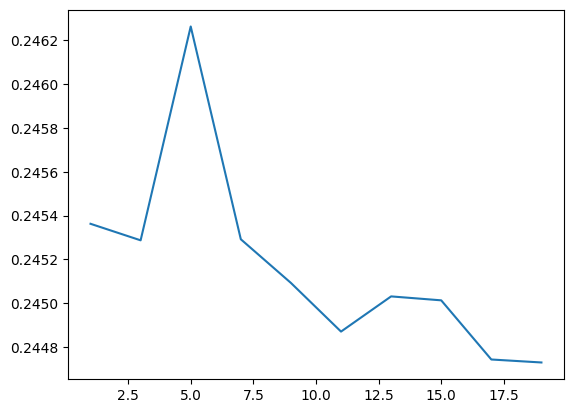

In [24]:
import matplotlib.pyplot as plt


plt.plot(histories.keys(), [history["train_objective"].iloc[-1] for history in histories.values()])


## Create MODEL

In [ ]:
params = CN3SParams(area=data["area"])
model = CN3S(params)

In [9]:
params

CN3SParams(area=34334.0, r0=350.0, cn_i=7.35, alfa=0.2, beta=0.00211662329536844, k0=1.0, k1=0.316, k2=0.305, act=0, warmup_steps=3)

In [21]:
model.run(data["prec"]["prec"])

Running CN3S model:   0%|          | 0/9666 [00:00<?, ?step/s]

In [29]:
model.results.index = model.results.index - pd.Timedelta(hours=12)

In [30]:
model.evaluate(data["q"]["Vazao"])

Aligned 9513 time steps between model results and observations.
From 2000-01-04 00:00:00 to 2026-02-28 00:00:00.


-0.6534685614875377

In [31]:
model.plot()

## SCRATCH

In [42]:
from cn3s import CN3SOptimizer
from cn3s.objectives import Objectives

In [43]:
sliced_prec = data["prec"]["prec"].iloc[-2000:-1000]

model = CN3S(CN3SParams(area=data["area"], warmup_steps=10))

optim = CN3SOptimizer(
    prec=sliced_prec,
    observed_q=data["q"]["Vazao"],
    model=model,
    train_ratio=0.8,
    max_act=10,
    objective=Objectives.PlainNSE,
)

print(f"Aligned record: {len(optim.aligned)} time steps")
print(f"Train: {optim.train_idx} | Test: {len(optim.aligned) - optim.train_idx}")

Aligned record: 1000 time steps
Train: 800 | Test: 200


In [45]:
print(model, model.params)

<cn3s.model.CN3S object at 0x7f3a999c7440> CN3SParams(area=27898.35854781605, r0=350.0, cn_i=7.35, alfa=0.2, beta=0.00211662329536844, k0=1.0, k1=0.316, k2=0.305, act=0, warmup_steps=10)


In [ ]:
optim.optimize(maxiter=2, disp=False, workers=-1)


/usr/local/lib/python3.12/dist-packages/scipy/optimize/_differentialevolution.py:487: UserWarning:

differential_evolution: the 'workers' keyword has overridden updating='immediate' to updating='deferred'



<cn3s.model.CN3S object at 0x7f3a9999dc40> CN3SParams(area=27898.35854781605, r0=149.13830156594082, cn_i=58.56574354849801, alfa=6.8307114690518915, beta=6.006294667001378, k0=10.629363000789615, k1=13.056107758648015, k2=1.9131631294198157, act=5, warmup_steps=10)
<cn3s.model.CN3S object at 0x7f3a9999d100> CN3SParams(area=27898.35854781605, r0=803.2840927978843, cn_i=127.75787121705253, alfa=82.52383427394076, beta=10.270070749523091, k0=13.95854882518377, k1=10.381721182458577, k2=1.7218080299804213, act=8, warmup_steps=10)
<cn3s.model.CN3S object at 0x7f3a9999d100> CN3SParams(area=27898.35854781605, r0=284.1504890866254, cn_i=55.72024437468054, alfa=60.91610449703717, beta=18.642622864937323, k0=26.553625572807803, k1=33.021092503972504, k2=0.36894911544095654, act=8, warmup_steps=10)
<cn3s.model.CN3S object at 0x7f3a9999c470> CN3SParams(area=27898.35854781605, r0=77.36055404171816, cn_i=2.02201787939066, alfa=38.448106343647275, beta=1.6215930871675237, k0=27.700745695002848, k1=1

Process ForkPoolWorker-5:
Process ForkPoolWorker-2:
Process ForkPoolWorker-4:
Process ForkPoolWorker-1:
Process ForkPoolWorker-3:
Process ForkPoolWorker-6:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/usr/lib/python3.12/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/usr/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/usr/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/usr/lib/python3.12/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/lib/python3.12/multiprocessing/pool.py", line 114, in worker
    ta

## Evaluate Results

In [29]:
results = model.results.copy()
results.index = prec.index[3:]

results = pd.concat([results, q], axis=1)
results = results.dropna()
results

,prec,past_prec,vj,cnv,s,q_up,r1,q_low,r,q_mm,q_m3s,EstacaoCodigo,NivelConsistencia,Vazao
2000-01-04,0.001623,"[3.5876622200012207, 4.615259647369385, 4.9626...",1.03,7.359826,3197.17,0.0,350.0,106.75,243.25,106.75,1414.03,66010000.0,2.0,101.48
2000-01-05,0.38961,"[0.001623376621864736, 3.5876622200012207, 4.6...",1.02,7.259946,3244.65,0.0,243.37,74.23,169.14,74.23,983.26,66010000.0,2.0,88.84
2000-01-06,0.724026,"[0.3896103799343109, 0.001623376621864736, 3.5...",1.01,7.160458,3293.26,0.0,169.37,51.66,117.71,51.66,684.3,66010000.0,2.0,69.90
2000-01-07,6.633117,"[0.7240259647369385, 0.3896103799343109, 0.001...",1.0,7.061363,3343.04,0.0,119.81,36.54,83.27,36.54,484.01,66010000.0,2.0,67.17
2000-01-08,3.660714,"[6.633116722106934, 0.7240259647369385, 0.3896...",1.02,7.259946,3244.65,0.0,84.43,25.75,58.68,25.75,341.09,66010000.0,2.0,109.21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-27,8.561688,"[1.829545497894287, 0.04707792028784752, 7.733...",1.02,7.259946,3244.65,0.0,7.67,2.34,5.33,2.34,31.0,66010000.0,1.0,125.14
2025-12-28,1.498377,"[8.561688423156738, 1.829545497894287, 0.04707...",1.02,7.259946,3244.65,0.0,5.8,1.77,4.03,1.77,23.45,66010000.0,1.0,115.80
2025-12-29,3.35552,"[1.4983766078948975, 8.561688423156738, 1.8295...",1.03,7.359826,3197.17,0.0,5.09,1.55,3.54,1.55,20.53,66010000.0,1.0,112.90
2025-12-30,6.820617,"[3.3555195331573486, 1.4983766078948975, 8.561...",1.03,7.359826,3197.17,0.0,5.7,1.74,3.96,1.74,23.05,66010000.0,1.0,107.13


<Axes: title={'center': 'Model Results vs Observed Discharge'}>

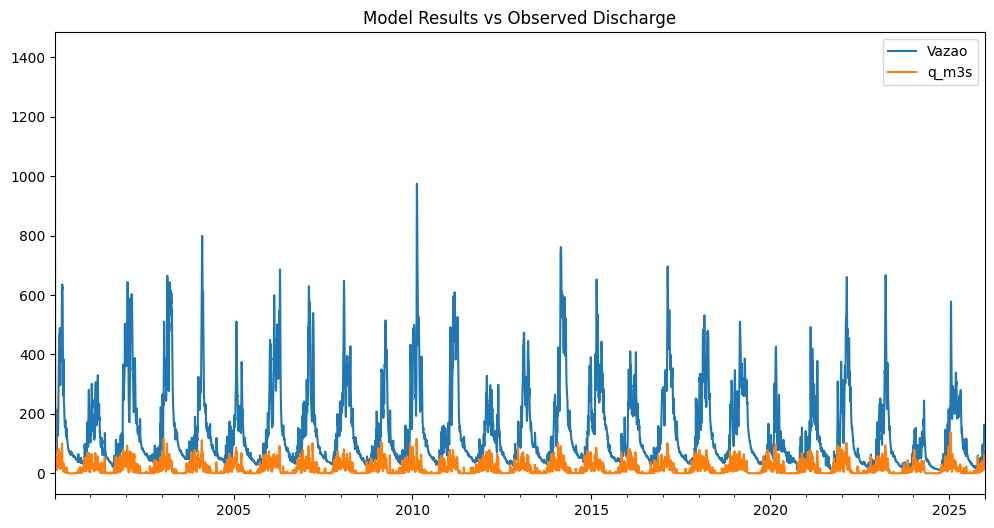

In [30]:
results.plot(y=["Vazao", "q_m3s"], figsize=(12, 6), title="Model Results vs Observed Discharge")

In [33]:
r2_score(results["Vazao"], results["q_m3s"])

-0.7509780352225082

In [13]:
r2_score(results["Vazao"], [results["Vazao"].mean()] * len(results))

0.0